In [8]:
import sys

import numpy as np
import pandas as pd

sys.path.append("../src")
from utils import code_fix

In [9]:
gdp = pd.read_csv("../data/gdp_per_capita/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv", skiprows=4, encoding="utf-8-sig")
year_cols = [c for c in gdp.columns if c.isdigit()]

ranks = gdp[year_cols].rank(ascending=False, method="min", na_option="keep")
n = gdp[year_cols].count()
gdp[year_cols] = 1 - (ranks - 1) / (n - 1)

gdp_long = gdp[["Country Name", "Country Code", *year_cols]].melt(
    id_vars=["Country Name", "Country Code"],
    var_name="year",
    value_name="gdp_usd"
)

gdp_long["year"] = pd.to_numeric(gdp_long["year"], errors="coerce").astype("Int64")

In [10]:
olympic_df = pd.read_csv("../data/olympic_medals.csv")
olympic_df = olympic_df[olympic_df["year"] >= 1960].copy()
olympic_df["Country Code"] = olympic_df["country_code"].str.upper().str.strip().replace(code_fix)

In [11]:
merged = olympic_df.merge(
    gdp_long[["Country Code", "year", "gdp_usd"]],
    on=["Country Code", "year"],
    how="left"
)

In [5]:
# aggregate mean GDP by year and sport
gdp_by_sport_year = merged.groupby(["sport","year"]).agg(
    mean_gdp=pd.NamedAgg(column="gdp_usd", aggfunc="mean")
).reset_index()

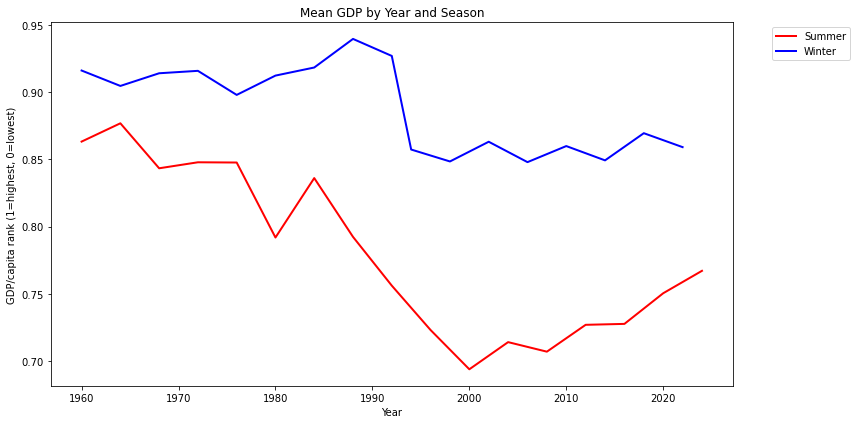

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
gdp_by_year_summer = merged[merged["season"] == "Summer"].groupby("year").agg({"gdp_usd": "mean"}).reset_index()
plt.plot(gdp_by_year_summer["year"], gdp_by_year_summer["gdp_usd"], label="Summer", color="red", linewidth=2)
gdp_by_year_winter = merged[merged["season"] == "Winter"].groupby("year").agg({"gdp_usd": "mean"}).reset_index()
plt.plot(gdp_by_year_winter["year"], gdp_by_year_winter["gdp_usd"], label="Winter", color="blue", linewidth=2)

plt.xlabel("Year")
plt.ylabel("GDP/capita rank (1=highest, 0=lowest)")
plt.title("Mean GDP by Year and Season")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../figures/gdp_rank_by_year.png", dpi=300)
plt.show()

In [7]:
gdp_by_sport = gdp_by_sport_year.groupby("sport", as_index=False)["mean_gdp"].mean()
gdp_by_sport["mean_gdp"] = (gdp_by_sport["mean_gdp"] * 100).map(lambda x: f"{x:.1f}%")
gdp_by_sport = gdp_by_sport.sort_values("mean_gdp", ascending=False)
print(gdp_by_sport.head(10).to_markdown(index=False))
print(gdp_by_sport.tail(10).to_markdown(index=False))

| sport               | mean_gdp   |
|:--------------------|:-----------|
| Ice Hockey          | 91.9%      |
| Alpine Skiing       | 91.5%      |
| Curling             | 91.4%      |
| Nordic Combined     | 91.3%      |
| Equestrian Dressage | 91.0%      |
| Equestrian          | 91.0%      |
| Bobsleigh           | 90.9%      |
| Softball            | 90.8%      |
| Speed skating       | 90.3%      |
| Snowboard           | 90.3%      |
| sport               | mean_gdp   |
|:--------------------|:-----------|
| Hockey              | 67.3%      |
| Karate              | 66.6%      |
| Taekwondo           | 66.5%      |
| Gymnastics Rhythmic | 66.0%      |
| Trampoline          | 64.7%      |
| Weightlifting       | 64.7%      |
| Wrestling           | 62.4%      |
| Table Tennis        | 57.5%      |
| Badminton           | 56.5%      |
| Artistic swimming   | 54.0%      |
